# Interacting with prop datasets

To know
- Distribution of lengths -> compute cut-offs
- Distribution of splits -> compute splits

In [42]:
from multiprocessing import Pool

import datasets
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer
from tqdm import tqdm

from prop import *

In [43]:
# ds_path = full_text_ds_path
ds_path = '/n/home09/wlt/scratch/data/prop_gen/data/hf_php_text_2048'
ds = datasets.load_from_disk(ds_path)
ds

DatasetDict({
    True_9: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 8
    })
    True_143: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 64
    })
    False_143: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 256
    })
    True_142: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 16
    })
    True_145: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 192
    })
    True_144: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 128
    })
    True_149: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 64
    })
    True_146: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 224

Text(0, 0.5, 'number of examples')

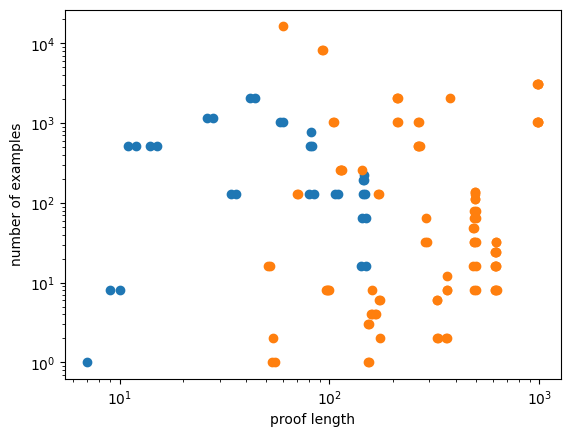

In [44]:
t_vals = []
f_vals = []

for k, v in ds.items():
    name, num = k.split('_')

    if name == 'True':
        t_vals.append((int(num), len(v)))
    else:
        f_vals.append((int(num), len(v)))
        
# <codecell>
import matplotlib.pyplot as plt

t_idx, t_lens = np.array(t_vals).T
f_idx, f_lens = np.array(f_vals).T
plt.scatter(t_idx, t_lens)
plt.scatter(f_idx, f_lens)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('proof length')
plt.ylabel('number of examples')

prop | t_idx | f_idx
----------------------
 0.2:    15     55
 0.4:    36     92
 0.5:    42    104
 0.6:    42    210
 0.8:    80    980
0.95:   144    986


Text(0, 0.5, 'cumulative proportion of examples')

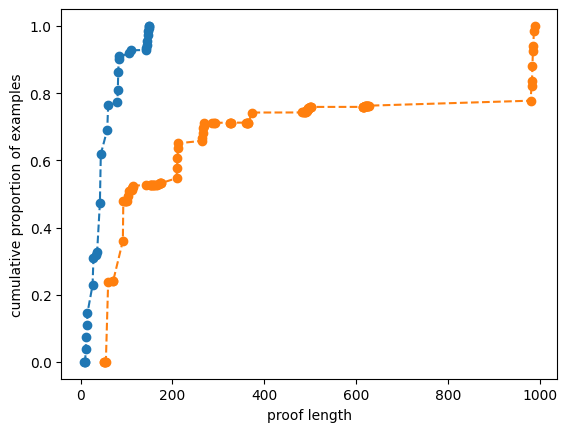

In [45]:
t_sort_idx = np.argsort(t_idx)
t_cum = np.cumsum(t_lens[t_sort_idx]) / np.sum(t_lens)

f_sort_idx = np.argsort(f_idx)
f_cum = np.cumsum(f_lens[f_sort_idx]) / np.sum(f_lens)

plt.plot(np.sort(t_idx), t_cum, 'o--')
plt.plot(np.sort(f_idx), f_cum, 'o--')

props = [0.2, 0.4, 0.5, 0.6, 0.8, 0.95]

t_idxs = []
f_idxs = []
for p in props:
    idx = np.sum(t_cum < p) - 1
    t_idxs.append(t_idx[t_sort_idx][idx].item())
    
    idx = np.sum(f_cum < p) - 1
    f_idxs.append(f_idx[f_sort_idx][idx].item())

print(f'prop | t_idx | f_idx')
print('----------------------')
for prop, t, f in zip(props, t_idxs, f_idxs):
    print(f'{prop:4}: {t:5} {f:6}')

plt.xlabel('proof length')
plt.ylabel('cumulative proportion of examples')

In [46]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-Coder-7B')

def to_toks(ex):
    inp_and_proof_toks = tokenizer(ex['prompt'] + ex['completion'], return_attention_mask=False)

    return {
        'tok_len': len(inp_and_proof_toks['input_ids']),
    }

ds = ds.map(to_toks, batched=False, num_proc=16)

num_proc must be <= 8. Reducing num_proc to 8 for dataset of size 8.


Map (num_proc=8):   0%|          | 0/8 [00:00<?, ? examples/s]

Map (num_proc=16):   0%|          | 0/64 [00:00<?, ? examples/s]

Map (num_proc=16):   0%|          | 0/256 [00:00<?, ? examples/s]

Map (num_proc=16):   0%|          | 0/16 [00:00<?, ? examples/s]

...

Map (num_proc=2):   0%|          | 0/2 [00:00<?, ? examples/s]

num_proc must be <= 3. Reducing num_proc to 3 for dataset of size 3.


Map (num_proc=3):   0%|          | 0/3 [00:00<?, ? examples/s]

num_proc must be <= 1. Reducing num_proc to 1 for dataset of size 1.


Map:   0%|          | 0/1 [00:00<?, ? examples/s]

In [47]:
def get_len(ex):
    return ex['tok_len']

all_lens = []
for name, sub_ds in ds.items():
    print(f'info: parsing {name}')
    with Pool(16) as pool:
        lens = pool.map(get_len, sub_ds)
    all_lens.extend(lens)


info: parsing True_9
info: parsing True_143
info: parsing False_143
info: parsing True_142
info: parsing True_145
info: parsing True_144
info: parsing True_149
info: parsing True_146
info: parsing True_147
info: parsing True_148
info: parsing False_152
info: parsing False_172
info: parsing False_209
info: parsing False_210
info: parsing False_211
info: parsing False_212
info: parsing False_213
info: parsing False_104
info: parsing False_105
info: parsing False_361
info: parsing False_363
info: parsing False_96
info: parsing False_100
info: parsing False_112
info: parsing False_113
info: parsing False_114
info: parsing False_115
info: parsing False_170
info: parsing False_287
info: parsing False_290
info: parsing False_293
info: parsing False_490
info: parsing False_491
info: parsing False_493
info: parsing False_489
info: parsing False_488
info: parsing False_496
info: parsing False_492
info: parsing False_494
info: parsing False_499
info: parsing False_495
info: parsing False_498
info

array([ 20802.  ,  23119.  ,  51180.  , 146930.  , 148296.  , 150099.04])

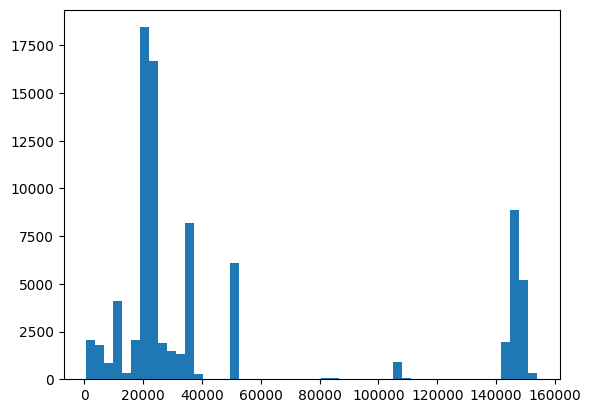

In [48]:
plt.hist(all_lens, bins=50)
np.quantile(all_lens, [0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

In [49]:
max(all_lens)

153931

In [56]:
example = ds['False_497'][0]
out = tokenizer(example['prompt'] + example['completion'], return_attention_mask=False)
len(out['input_ids'])

1